# Mxf ANN Model Demo

### Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
rc('mathtext', fontset='cm')
from typing import Tuple, Dict, List
from IPython.display import display, Latex
from sklearn.metrics import explained_variance_score, max_error, mean_absolute_error,  mean_squared_error, r2_score, mean_absolute_percentage_error


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchmetrics, mlxtend

import torchinfo
from torchinfo import summary

import os
import re
import time


#### Set the device: cuda or cpu

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    torch.cuda.set_device(device)

#### Get the data and create some useful features as extensions

#### Min and max values of stellar parameters

In [3]:
C_min = 0.095273; C_max = 0.306475;
x_min = 0.140648; x_max = 0.202447;
Mxf_min = 0.00079856; Mxf_max = 0.00610166;

### min-max scaling

In [4]:
min_values = np.array([x_min, C_min])
max_values = np.array([x_max, C_max])

# min-max scaling function
feature_scaler = lambda data: (data - min_values) / (max_values - min_values)

#### Input layer features: model's input parameters

In [5]:
selected_features = ['x','C'] 

#### Test subample of NS configurations 

In [6]:
df_test = pd.read_csv("NS_data/test_data_relatively_slow_rot_conf_small_sample.csv")

In [7]:
df_test

,C,x,Qbar,Mxfhat,EoS
0,0.274288,0.148618,1.850285,0.004124,SkOp
1,0.188028,0.146573,4.554646,0.002160,QHC21-CT
2,0.138709,0.151386,8.147240,0.001355,DS(CMF)-3
3,0.129106,0.168744,8.847651,0.001385,RMF4
4,0.253535,0.147812,2.306878,0.003548,BSK22
...,...,...,...,...,...
423,0.181573,0.179808,4.849369,0.002516,DNS
424,0.266069,0.150634,2.100849,0.003830,BSK24
425,0.231998,0.178583,2.800615,0.003760,DS(CMF)-6
426,0.170897,0.164532,5.489028,0.002089,DS(CMF)-7


In [8]:
def load_stars(data_frame, batch_size = 2048, shuffle = True): 
    
    
    df_target = (data_frame['Mxfhat']) 
    np_features = data_frame[selected_features].to_numpy()    
    
    np_targets = df_target.to_numpy()
    np_targets = np.reshape(np_targets, (np_targets.shape[0], 1))
    
    tensor_features = torch.Tensor(feature_scaler(np_features)) 
    
    input_dimension = tensor_features.shape[1]
    
    tensor_targets = torch.Tensor(np_targets)
    final_dataset = TensorDataset(tensor_features, tensor_targets)

    dataloader = DataLoader(final_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=5, pin_memory=True)

    return dataloader, input_dimension, np_features, np_targets

#### Dataloader

In [9]:
batch_size = 16
test_dataloader, input_dimension, _, _ = load_stars(df_test, batch_size = batch_size)

#### Feed-forward ANN Model to perform regression

In [10]:
class ModifiedSigmoid(nn.Module):
    def forward(self, x):
        return Mxf_min + (Mxf_max - Mxf_min)*torch.sigmoid(x) 

In [11]:
class RegressorModel(nn.Module):
    def __init__(self,input_dimension, feature_scaler):
        super().__init__()
        
        self.feature_scaler = feature_scaler
        
        self.MLP = nn.Sequential(
            
            nn.Linear(input_dimension, 120),
            nn.GELU(),
            nn.Linear(120, 75),  
            nn.GELU(),
            nn.Linear(75, 50), 
            nn.GELU(),
            nn.Linear(50, 25),  
            nn.GELU(),
            nn.Linear(25, 10),  
            nn.GELU(),
            nn.Linear(10, 1),  
            ModifiedSigmoid(), # a modification of sigmoid activation function 

        )
        # Initialize weights
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.01)

    def forward(self, x):
        x = self.MLP(x)
        return x
    
    def predict(self, x):
        x = self.feature_scaler(x).astype('float32')
        x = torch.from_numpy(x).to(self.device)
        x = self.MLP(x)
        x = x.cpu().detach().numpy()
        return x
        
    def set_device(self, device):
        self.device = device    


In [12]:
model_0 = RegressorModel(input_dimension = input_dimension, feature_scaler = feature_scaler)
model_0

RegressorModel(
  (MLP): Sequential(
    (0): Linear(in_features=2, out_features=120, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=120, out_features=75, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=75, out_features=50, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=50, out_features=25, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=25, out_features=10, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=10, out_features=1, bias=True)
    (11): ModifiedSigmoid()
  )
)

In [13]:
summary(model_0)

Layer (type:depth-idx)                   Param #
RegressorModel                           --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       360
│    └─GELU: 2-2                         --
│    └─Linear: 2-3                       9,075
│    └─GELU: 2-4                         --
│    └─Linear: 2-5                       3,800
│    └─GELU: 2-6                         --
│    └─Linear: 2-7                       1,275
│    └─GELU: 2-8                         --
│    └─Linear: 2-9                       260
│    └─GELU: 2-10                        --
│    └─Linear: 2-11                      11
│    └─ModifiedSigmoid: 2-12             --
Total params: 14,781
Trainable params: 14,781
Non-trainable params: 0

### ANN Model evaluation 

#### Load the trained Model best weights $\theta^\star$

In [14]:
batch_size = 16
model_path = './Model-Weights/Mxf_inference/model.pth'
dataloader_test, _, np_features_test, np_targets_test = load_stars(df_test, batch_size=batch_size)

In [15]:
regressor = RegressorModel(input_dimension = input_dimension, feature_scaler = feature_scaler).to(device)
regressor.set_device(device)
regressor.load_state_dict(torch.load(model_path, map_location=torch.device(device)))
regressor.eval()

RegressorModel(
  (MLP): Sequential(
    (0): Linear(in_features=2, out_features=120, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=120, out_features=75, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=75, out_features=50, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=50, out_features=25, bias=True)
    (7): GELU(approximate='none')
    (8): Linear(in_features=25, out_features=10, bias=True)
    (9): GELU(approximate='none')
    (10): Linear(in_features=10, out_features=1, bias=True)
    (11): ModifiedSigmoid()
  )
)

#### Residual Error - Fractional difference - Evaluation Measures

In [16]:
def plot_residuals(residual_error, percentage_error):
    witdh, height = 16, 6
    fontsize = 20
    labelsize = 15
    lw = 5
    
    fig, ax = plt.subplots(1, 2, figsize=(witdh, height))
    # Residual error subplot 
    ax[0].plot(residual_error, lw=lw)
    ax[0].set_xlabel(r'Datapoints', fontsize=fontsize)
    ax[0].set_ylabel(r'Residual', fontsize=fontsize)
    ax[0].tick_params(axis='both', which='both', labelsize=labelsize)

    # Percentage error subplot 
    ax[1].plot(percentage_error, lw=lw)
    ax[1].set_xlabel(r'Datapoints', fontsize=fontsize)
    ax[1].set_ylabel(r'$PE \ [\%]$', fontsize=fontsize)
    ax[1].tick_params(axis='both', which='both', labelsize=labelsize)

    plt.tight_layout()
    plt.show()
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    fontsize = 20
    labelsize = 15
    lw = 5

    # Residual error histogram
    ax[0].hist(residual_error, bins = 20)
    ax[0].set_ylabel(r'Datapoints', fontsize=fontsize)
    ax[0].set_xlabel(r'Residual', fontsize=fontsize)
    ax[0].tick_params(axis='both', which='both', labelsize=labelsize)

    # Percentage error histogram
    ax[1].hist(percentage_error, bins = 20)
    ax[1].set_ylabel(r'Datapoints', fontsize=fontsize)
    ax[1].set_xlabel(r'$PE \ [\%]$', fontsize=fontsize)
    ax[1].tick_params(axis='both', which='both', labelsize=labelsize)

    plt.tight_layout()
    plt.show()

In [17]:
def Evaluation_Measures(y_true, y_pred):    

    exp_var = explained_variance_score(y_true, y_pred)
    max_err = max_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    measures = {'explained_variance': [exp_var], 
                'max_error': [max_err],
                'mean_absolute_error': [mae],
                'mean_squared_error': [mse],
                'r2_score': [r2],
                'mean_absolute_percentage_error': [mape]}
   
    df_eval_measures = pd.DataFrame(measures)
    
    return df_eval_measures

#### Evaluation measures in Test Set subsample

In [18]:
np_targets_test = np_targets_test.ravel()

model_estimation_test_set = regressor.predict(np_features_test)
model_estimation_test_set = model_estimation_test_set.ravel().astype(np.float64) 

In [19]:
test_eval_measures = Evaluation_Measures(y_true = np_targets_test, y_pred = model_estimation_test_set)
test_eval_measures

,explained_variance,max_error,mean_absolute_error,mean_squared_error,r2_score,mean_absolute_percentage_error
0,0.999992,0.000014,0.000002,9.703797e-12,0.999992,0.000942


#### Redidual Errors and Pecentange Errors in the test Set subsample

In [20]:
residual_error_test = model_estimation_test_set - np_targets_test
percentage_error_test = (residual_error_test / np_targets_test) * 100

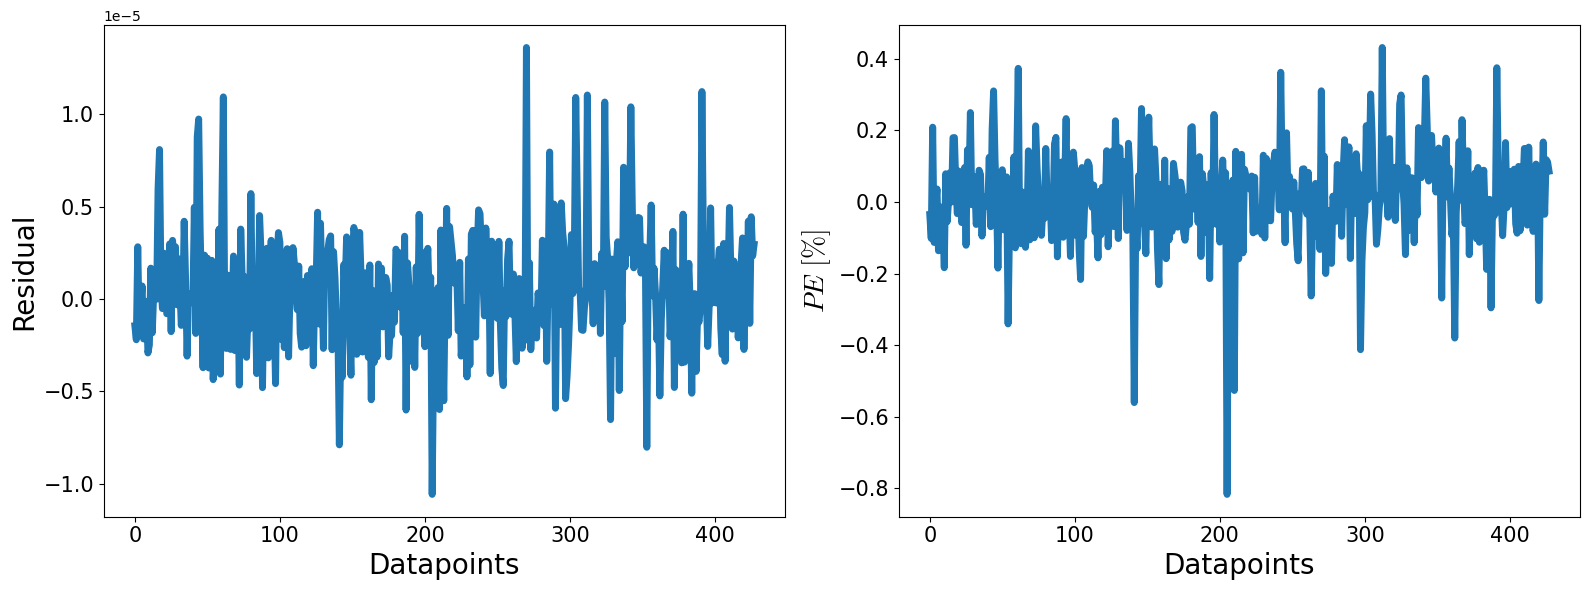

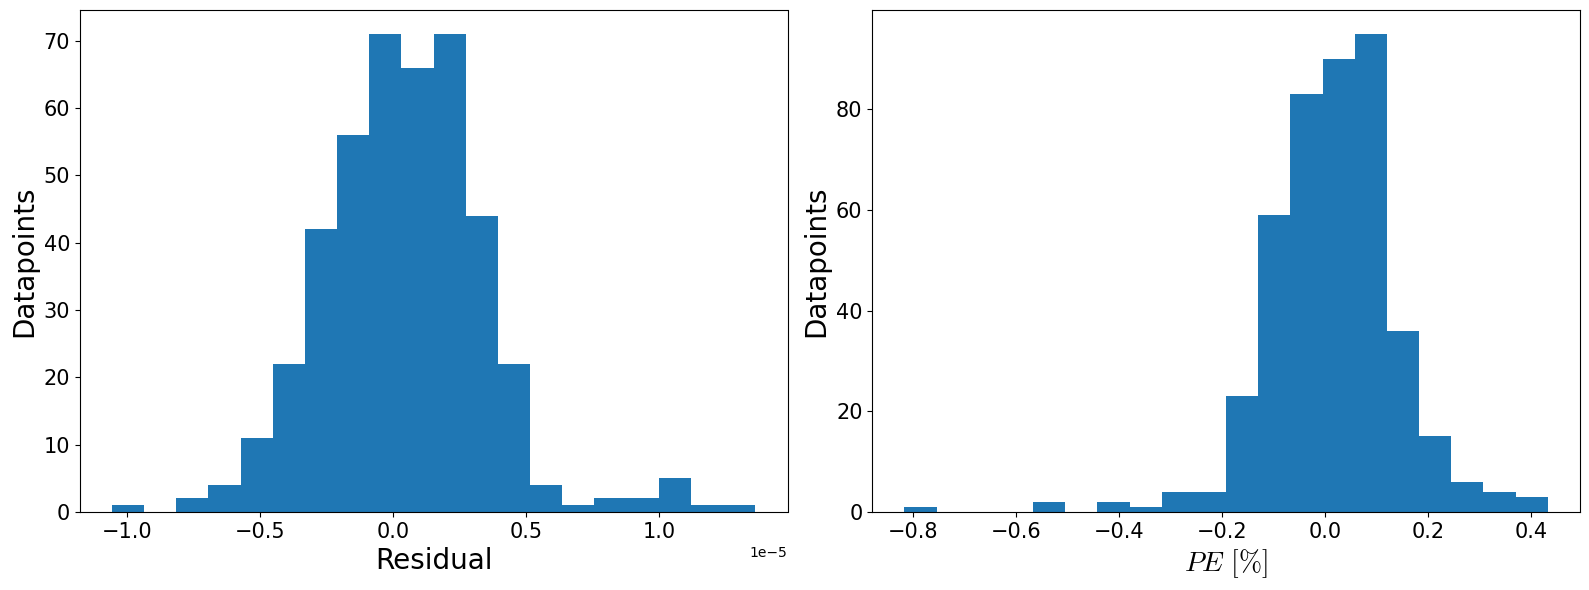

In [21]:
plot_residuals(residual_error_test, percentage_error_test)

In [22]:
df_test['Mxfhat_model'] = model_estimation_test_set

In [23]:
def mesh_grid_funct(number_of_points, data_frame,x_name, y_name):
    
    number_of_points = number_of_points
    
    x = np.linspace(data_frame[x_name].min(), data_frame[x_name].max(),number_of_points)
    y = np.linspace(data_frame[y_name].min(), data_frame[y_name].max(),number_of_points)
    
    X,Y = np.meshgrid(x, y)
    
    return X,Y

In [24]:
x_d = mesh_grid_funct(1000,df_test,x_name = 'x', y_name = 'C')[0]
y_d = mesh_grid_funct(1000,df_test, x_name = 'x', y_name = 'C')[1]

In [25]:
def Mxfhat_model(x,y):
    x_flat = x.flatten()
    y_flat = y.flatten()    
    input_features = np.column_stack((x_flat, y_flat))
    ANN_estimation = regressor.predict(input_features)
    ANN_estimation = ANN_estimation.ravel().astype(np.float64) 
    return ANN_estimation.reshape(x.shape)

In [26]:
Z = Mxfhat_model(x_d,y_d)
Z

array([[0.00093772, 0.0009375 , 0.00093729, ..., 0.001067  , 0.00106678,
        0.00106656],
       [0.0009399 , 0.00093969, 0.00093947, ..., 0.00106969, 0.00106947,
        0.00106925],
       [0.0009421 , 0.00094188, 0.00094166, ..., 0.00107238, 0.00107216,
        0.00107194],
       ...,
       [0.00472863, 0.00472875, 0.00472889, ..., 0.00563735, 0.0056352 ,
        0.00563304],
       [0.00473332, 0.00473344, 0.00473357, ..., 0.00564778, 0.00564564,
        0.0056435 ],
       [0.004738  , 0.00473812, 0.00473825, ..., 0.0056582 , 0.00565608,
        0.00565394]])

In [27]:
x = 'x'; y = 'C'; w = 'Qbar'; z = 'Mxfhat'; 

In [28]:
def Surface_plot(df,x,y,w,z, xlabel,ylabel,wlabel, zlabel, view2, n_col, border_axes, X,Y, Z, l_w):
    
    fig = plt.figure(figsize=(12 ,8)) 
    labels_text_size = 20
    ax = fig.add_subplot(111, projection='3d')

    dot_size = 40
    font_size = 22
    label_pad = 20
    label_size = 18

    
    #######################################################################################################
   
    scatter = ax.scatter(df[x].to_numpy(),df[y].to_numpy(),1000*df[z].to_numpy(),
                    c = df[w].to_numpy(), s = dot_size, cmap = 'viridis', marker='o', label = 'Test Data')    
   

    cbar = plt.colorbar(scatter,  shrink=0.5)
    cbar.set_label(wlabel, fontsize=font_size, rotation=0)
    cbar.ax.tick_params(labelsize=15)
    
    ax.plot_wireframe(X, Y, 1000*Z, rstride=30, cstride=30,edgecolor='blue' ,color = 'darkolivegreen',
                      alpha=0.6, lw = l_w, antialiased=True, label = r'ANN predicted wireframe')
    
    #######################################################################################################
    
    
    
    ax.view_init(30, view2)   
    ax.set_xlabel(xlabel, fontsize=font_size,labelpad=label_pad, rotation = 90) 
    ax.yaxis.set_rotate_label(False)
    ax.set_ylabel(ylabel, fontsize=font_size,labelpad=label_pad, rotation = 0) 
    
    ax.zaxis.set_rotate_label(False)
    ax.set_zlabel(zlabel, fontsize=font_size,labelpad=label_pad, rotation = 90)
    
    ax.yaxis._axinfo['label']['space_factor'] = 3.0   

    ax.zaxis.labelpad = 0
    ax.zaxis._axinfo['label']['space_factor'] = 0

    
    ax.xaxis.set_tick_params(labelsize=label_size)
    ax.yaxis.set_tick_params(labelsize=label_size)
    ax.zaxis.set_tick_params(labelsize=label_size)
    
    
    
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.line.set_linewidth(2)
    
    ax.grid(False)


    leg = plt.legend(loc="best",ncol=n_col, borderaxespad=border_axes, prop={'size': 12}, shadow=True, fontsize="large")    #,bbox_to_anchor=(1,1)
    leg.get_frame().set_linewidth(2.0)
    leg.get_frame().set_edgecolor('black')
    
    plt.tight_layout()    
    plt.show()

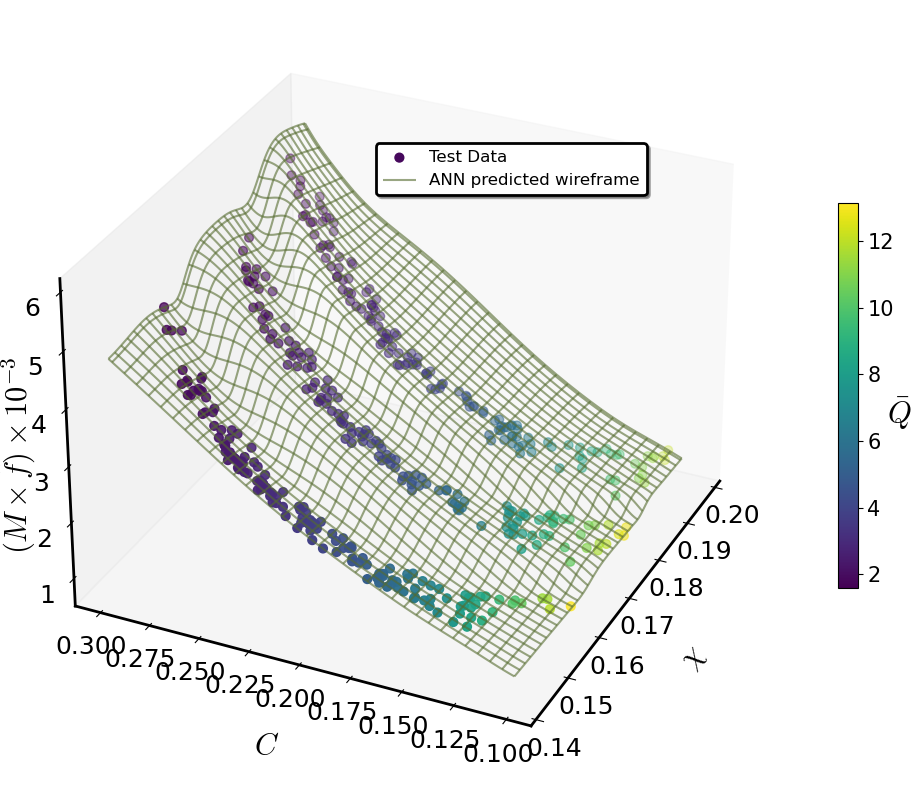

In [29]:
Surface_plot(df_test, x,y,w, z, xlabel=r'$\chi$',ylabel=r'$ C $',wlabel = r'$\bar{Q}$',
                    zlabel=r'$(M\times \hat{f})\times 10^{-3}$', 
                     view2=205, n_col=1, border_axes=8, X=x_d,Y=y_d,Z=Z, l_w=1.5)

In [30]:
def Mxf_ANN_model(x,y):
    input_features = np.column_stack((x, y))
    ANN_estimation = regressor.predict(input_features)
    ANN_estimation = ANN_estimation.ravel().astype(np.float64) 
    return ANN_estimation.reshape(x.shape)

In [31]:
Mxf_ANN_model(df_test['x'], df_test['C'])

array([0.0041225 , 0.00215783, 0.00135775, 0.00138304, 0.00354791,
       0.00195427, 0.00158214, 0.00490336, 0.00087542, 0.00491169,
       0.00134864, 0.00212468, 0.00330811, 0.00491756, 0.00136025,
       0.004233  , 0.00332886, 0.00450729, 0.00187877, 0.00158296,
       0.00287799, 0.00171747, 0.0013806 , 0.00150001, 0.00311272,
       0.00145609, 0.00218005, 0.00490883, 0.00113589, 0.00408165,
       0.00302649, 0.00136221, 0.0022662 , 0.00158041, 0.0047547 ,
       0.00125108, 0.00323698, 0.00335905, 0.00182533, 0.00208961,
       0.00163871, 0.00398472, 0.00269337, 0.0043514 , 0.00315098,
       0.00318001, 0.00422622, 0.0020064 , 0.00396053, 0.00231608,
       0.00246202, 0.00479365, 0.00129399, 0.00299579, 0.00127576,
       0.00335126, 0.00345072, 0.00210926, 0.00301469, 0.00316599,
       0.00431065, 0.00294282, 0.00161134, 0.0022893 , 0.00465472,
       0.00353552, 0.00214942, 0.00202597, 0.00163394, 0.00263615,
       0.00242572, 0.00205857, 0.00464847, 0.00178554, 0.00116

#### Model's fractional differences associated with the test set's subsample

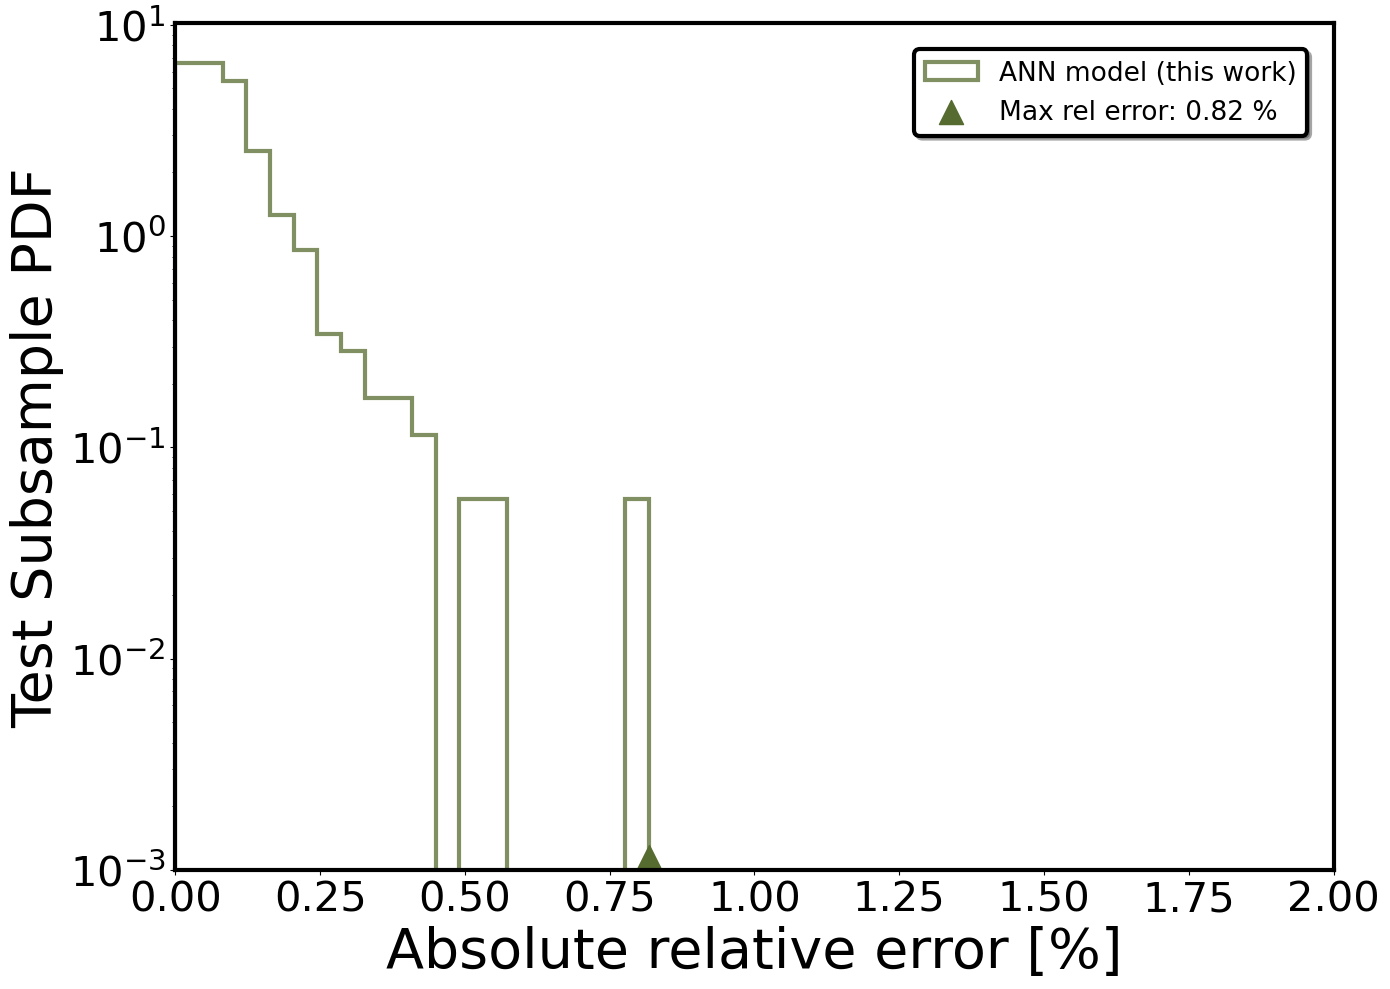

In [32]:
fig,ax = plt.subplots(figsize=(14, 10),)
labels_text_size = 40
plt.xticks(fontsize=30) 
plt.yticks(fontsize=30)

xlabel = r'Absolute relative error [%]'
ylabel = r'Test Subsample PDF'



plt.xlabel(xlabel,size=labels_text_size)
plt.ylabel(ylabel,size=labels_text_size)

bins = 20
alpha = 0.75

density = True

y_reg_model = (np.abs(100*(-df_test['Mxfhat'] + df_test['Mxfhat_model'])/df_test['Mxfhat'])).hist(
    density=density, 
    bins=bins, 
    lw=3, 
    edgecolor='darkolivegreen', 
    zorder=1, 
    histtype='step', 
    alpha=alpha, 
    label=f"ANN model (this work)", 
    color='darkolivegreen'
).autoscale(enable=True, axis='both', tight=True)

max_deviation = (np.abs(100*(-df_test['Mxfhat'] + df_test['Mxfhat_model'])/df_test['Mxfhat'])).max()

vertical_lines = [max_deviation] 

plt.scatter(vertical_lines[0], 1.15e-3, color='darkolivegreen',  marker='^', s=300, zorder=2, label=f'Max rel error: {np.round(max_deviation, 2)} %')  # Star marker

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(3.)


plt.yscale('log')

plt.xlim(0,2.)


plt.ylim(1e-3,10.2)

plt.grid(False)
leg = plt.legend(loc="upper right",ncol=1, borderaxespad=1, prop={'size': 19}, shadow=True, fontsize="large")   
leg.get_frame().set_linewidth(3.0)
leg.get_frame().set_edgecolor('black')


plt.tight_layout()
plt.show()